In [ ]:
# ============================================================
# Klasifikasi Gambar Jenis Domba dengan ResNet18, DenseNet121 & EfficientNet_B0
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random
import pandas as pd

# --------------------------
# Setup device
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device digunakan:", device)



Device digunakan: cuda


Jumlah kelas: 4
Kelas: ['animal sheep animal_face sheep_face marino', 'animal sheep animal_face sheep_face poll_dorset', 'animal sheep animal_face sheep_face suffolk', 'animal sheep animal_face sheep_face white_suffolk']


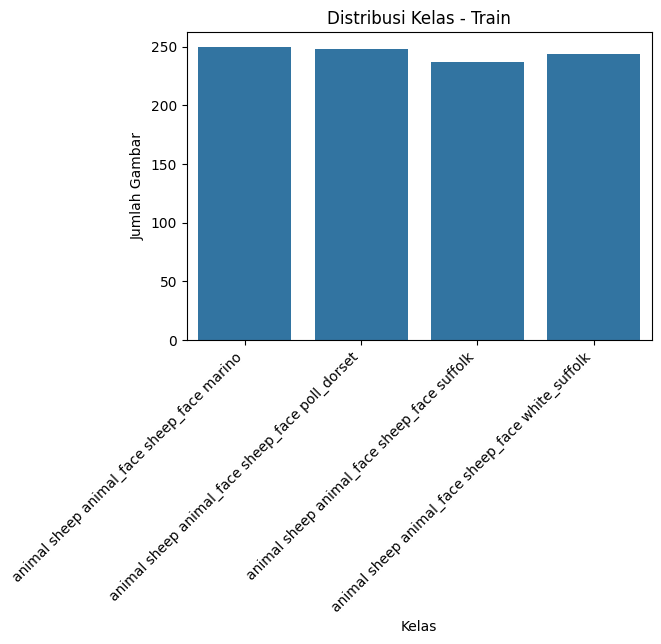

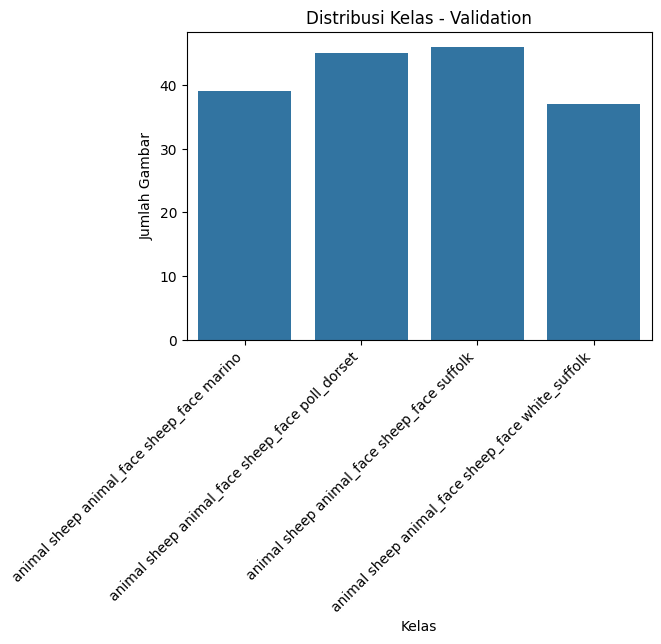

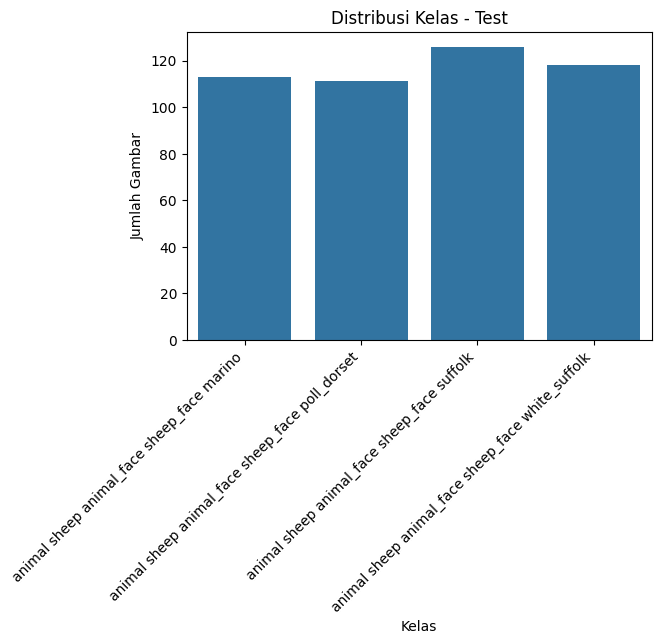


Contoh gambar dari Train Dataset:


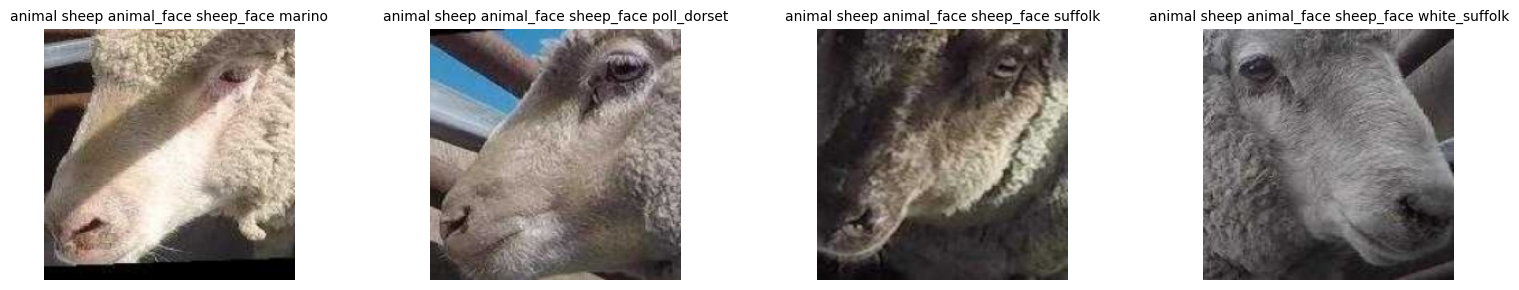

In [ ]:
# --------------------------
# Data Preparation
# --------------------------
data_dir = "dataset"
train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print("Jumlah kelas:", num_classes)
print("Kelas:", train_dataset.classes)

# ============================================================
# Exploratory Data Analysis (EDA)
# ============================================================
def plot_eda(dataset, title="Train Dataset"):
    class_counts = {}
    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    plt.figure(figsize=(6,4))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"Distribusi Kelas - {title}")
    plt.ylabel("Jumlah Gambar")
    plt.xlabel("Kelas")
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Distribusi data
plot_eda(train_dataset, "Train")
plot_eda(val_dataset, "Validation")
plot_eda(test_dataset, "Test")

# Tampilkan sample gambar (1 per kelas, grid 4 kolom)
def imshow_sample(dataset, cols=4):
    num_classes = len(dataset.classes)
    rows = (num_classes + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten()

    for i, class_name in enumerate(dataset.classes):
        idx = [j for j, (_, label) in enumerate(dataset) if label == i][0]
        img, label = dataset[idx]
        img = img.permute(1,2,0).numpy()
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=10)
        axes[i].axis("off")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

print("\nContoh gambar dari Train Dataset:")
imshow_sample(train_dataset)



c:\Users\Zharfan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Zharfan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\Zharfan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121


=== Training ResNet18 ===
Epoch 1/40: Train Loss=0.8028, Train Acc=0.7007 | Val Loss=2.5047, Val Acc=0.5389
Epoch 2/40: Train Loss=0.2881, Train Acc=0.8999 | Val Loss=0.8836, Val Acc=0.7126
Epoch 3/40: Train Loss=0.1611, Train Acc=0.9520 | Val Loss=0.4993, Val Acc=0.8204
Epoch 4/40: Train Loss=0.2107, Train Acc=0.9244 | Val Loss=0.3025, Val Acc=0.9162
Epoch 5/40: Train Loss=0.1164, Train Acc=0.9653 | Val Loss=0.2788, Val Acc=0.8982
Epoch 6/40: Train Loss=0.1130, Train Acc=0.9581 | Val Loss=0.3151, Val Acc=0.8743
Epoch 7/40: Train Loss=0.0993, Train Acc=0.9653 | Val Loss=0.3070, Val Acc=0.8922
Epoch 8/40: Train Loss=0.0975, Train Acc=0.9612 | Val Loss=0.2317, Val Acc=0.9281
Epoch 9/40: Train Loss=0.0508, Train Acc=0.9847 | Val Loss=0.7402, Val Acc=0.8084
Epoch 10/40: Train Loss=0.0474, Train Acc=0.9816 | Val Loss=0.3375, Val Acc=0.8802
Epoch 11/40: Train Loss=0.0295, Train Acc=0.9918 | Val Loss=0.2256, Val Acc=0.9281
Epoch 12/40: Train Loss=0.0342, Train Acc=0.9888 | Val Loss=0.2876, V

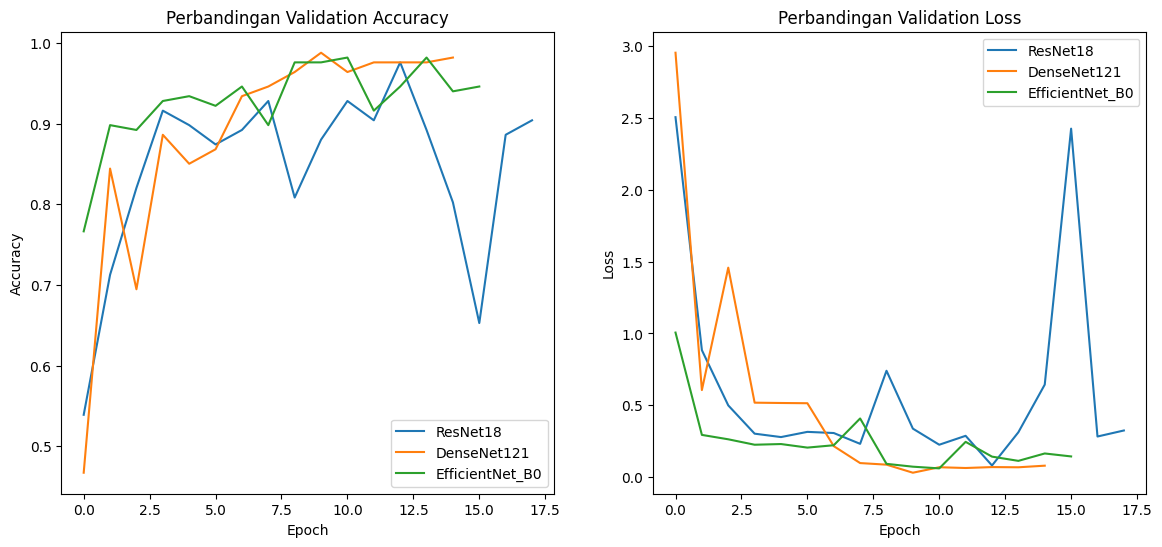

In [ ]:
# --------------------------
# Definisi Model
# --------------------------
def build_models(num_classes):
    resnet18 = models.resnet18(pretrained=True)
    num_ftrs1 = resnet18.fc.in_features
    resnet18.fc = nn.Linear(num_ftrs1, num_classes)
    resnet18 = resnet18.to(device)

    densenet121 = models.densenet121(pretrained=True)
    num_ftrs2 = densenet121.classifier.in_features
    densenet121.classifier = nn.Linear(num_ftrs2, num_classes)
    densenet121 = densenet121.to(device)

    efficientnet_b0 = models.efficientnet_b0(pretrained=True)
    num_ftrs3 = efficientnet_b0.classifier[1].in_features
    efficientnet_b0.classifier[1] = nn.Linear(num_ftrs3, num_classes)
    efficientnet_b0 = efficientnet_b0.to(device)

    return resnet18, densenet121, efficientnet_b0

# --------------------------
# Training Function (with early stopping)
# --------------------------
def train_model(model, criterion, optimizer, train_loader, val_loader,
                epochs=40, patience=5):
    best_acc = 0.0
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break

    model.load_state_dict(best_weights)
    return model, history

# --------------------------
# Evaluation Function 
# --------------------------
def evaluate_model(model, loader, criterion, phase="Validation"):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    print(f"\n=== {phase} Evaluation ===")
    print(f"{phase} Loss: {avg_loss:.4f}, {phase} Acc: {acc:.4f}")

    return avg_loss, acc

# ============================================================
# 6. Training & Evaluation
# ============================================================
criterion = nn.CrossEntropyLoss()
resnet18, densenet121, efficientnet_b0 = build_models(num_classes)

results = []

# --- ResNet18 ---
print("\n=== Training ResNet18 ===")
optimizer1 = optim.Adam(resnet18.parameters(), lr=0.001)
resnet18, hist1 = train_model(resnet18, criterion, optimizer1, train_loader, val_loader)
val_loss, val_acc = evaluate_model(resnet18, val_loader, criterion, "Validation")
test_loss, test_acc = evaluate_model(resnet18, test_loader, criterion, "Test")
results.append(["ResNet18", val_acc, val_loss, test_acc, test_loss])

# --- DenseNet121 ---
print("\n=== Training DenseNet121 ===")
optimizer2 = optim.SGD(densenet121.parameters(), lr=0.01, momentum=0.9)
densenet121, hist2 = train_model(densenet121, criterion, optimizer2, train_loader, val_loader)
val_loss, val_acc = evaluate_model(densenet121, val_loader, criterion, "Validation")
test_loss, test_acc = evaluate_model(densenet121, test_loader, criterion, "Test")
results.append(["DenseNet121", val_acc, val_loss, test_acc, test_loss])

# --- EfficientNet_B0 ---
print("\n=== Training EfficientNet_B0 ===")
optimizer3 = optim.Adam(efficientnet_b0.parameters(), lr=0.001)
efficientnet_b0, hist3 = train_model(efficientnet_b0, criterion, optimizer3, train_loader, val_loader)
val_loss, val_acc = evaluate_model(efficientnet_b0, val_loader, criterion, "Validation")
test_loss, test_acc = evaluate_model(efficientnet_b0, test_loader, criterion, "Test")
results.append(["EfficientNet_B0", val_acc, val_loss, test_acc, test_loss])

# --- Tabel Perbandingan ---
df_results = pd.DataFrame(results, columns=["Model", "Val Acc", "Val Loss", "Test Acc", "Test Loss"])
print("\n=== Perbandingan Hasil Evaluasi ===")
print(df_results)

# --- Plot Perbandingan Training History ---
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(hist1["val_acc"], label="ResNet18")
plt.plot(hist2["val_acc"], label="DenseNet121")
plt.plot(hist3["val_acc"], label="EfficientNet_B0")
plt.title("Perbandingan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist1["val_loss"], label="ResNet18")
plt.plot(hist2["val_loss"], label="DenseNet121")
plt.plot(hist3["val_loss"], label="EfficientNet_B0")
plt.title("Perbandingan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
